## Random Forest Regression.

In [1]:
#import libary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#load the data
df = pd.read_csv('House_Price_Prediction_Dataset.csv')

In [4]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [5]:
# Display first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
# Display first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
# Display column names
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [9]:
# Statistical summary
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [11]:
# Target column
print("Price is the target column we want to predict.")

Price is the target column we want to predict.


In [12]:
# Check missing values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

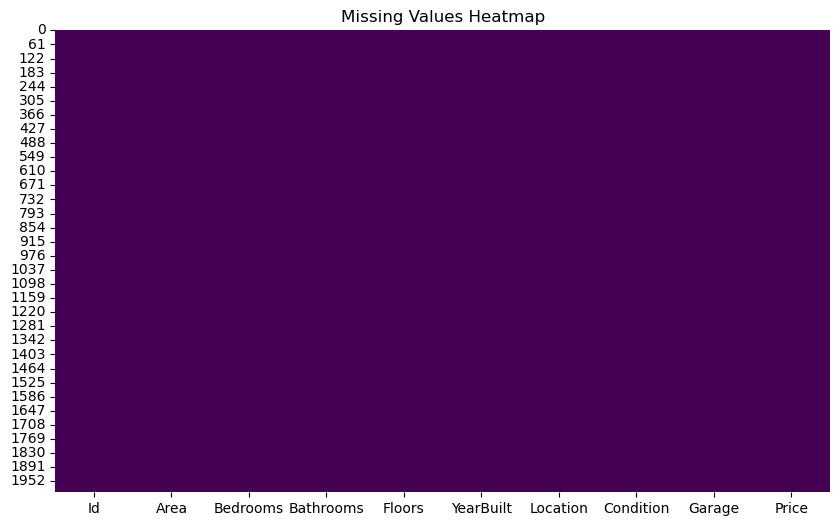

In [13]:
#heatmap to visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

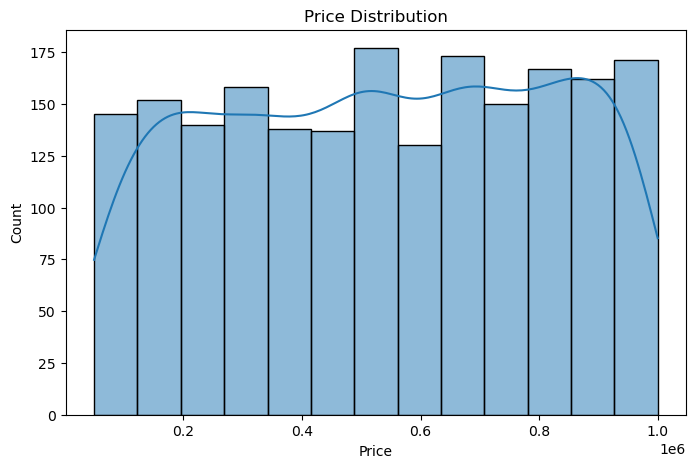

In [14]:
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

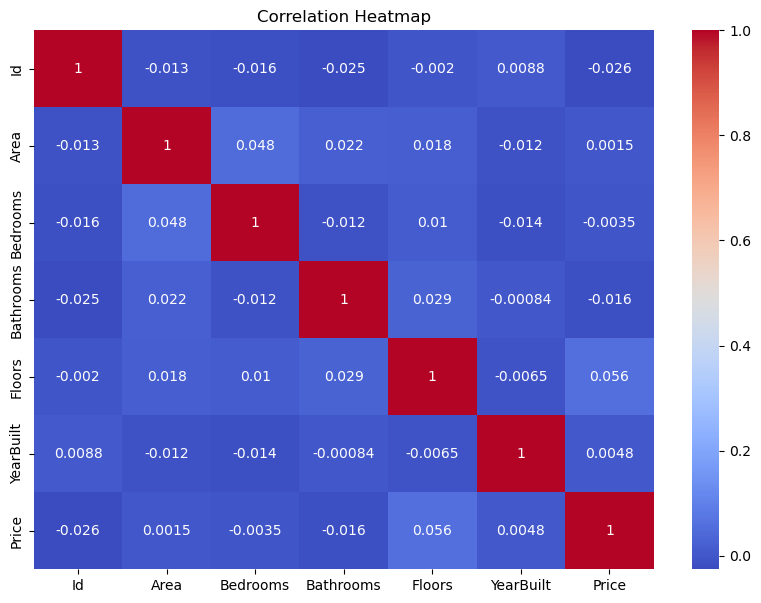

In [15]:
# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

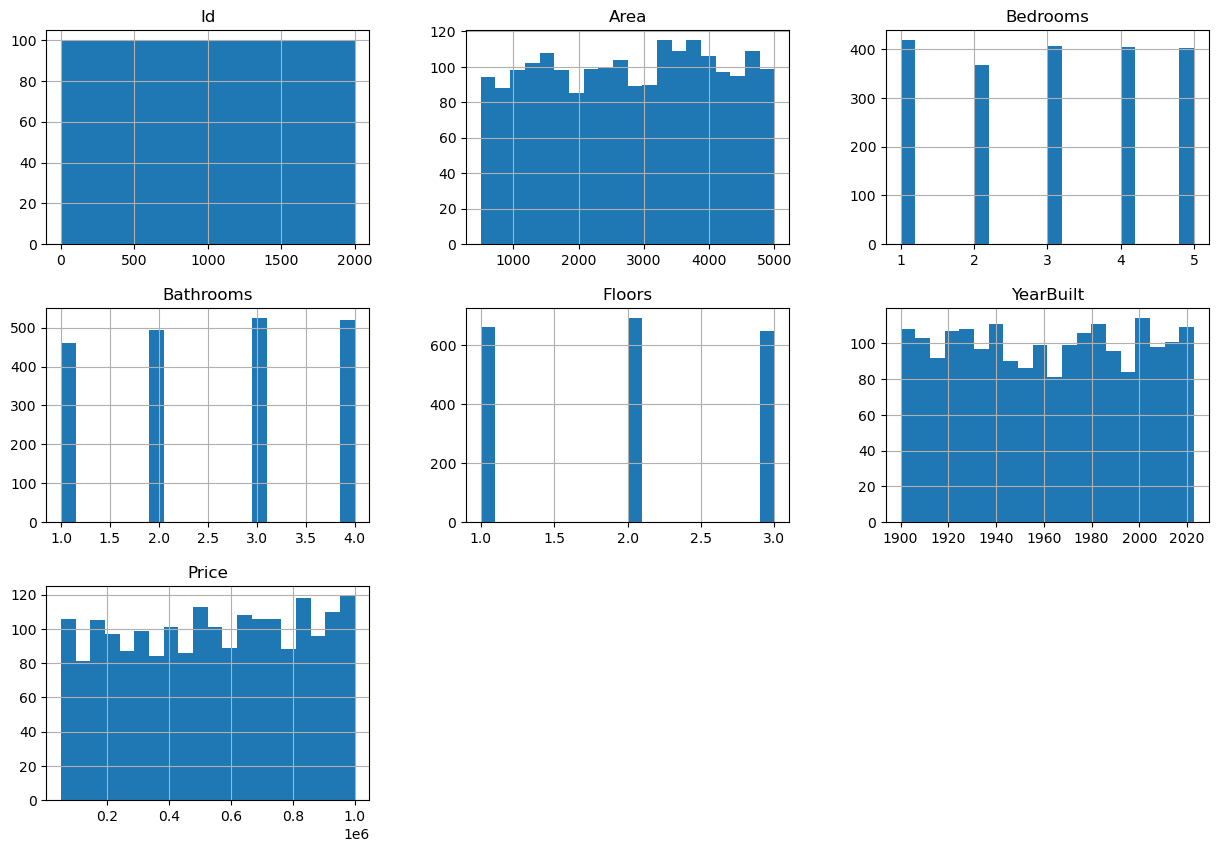

In [16]:
# Histograms
df.hist(figsize=(15,10), bins=20)
plt.show()

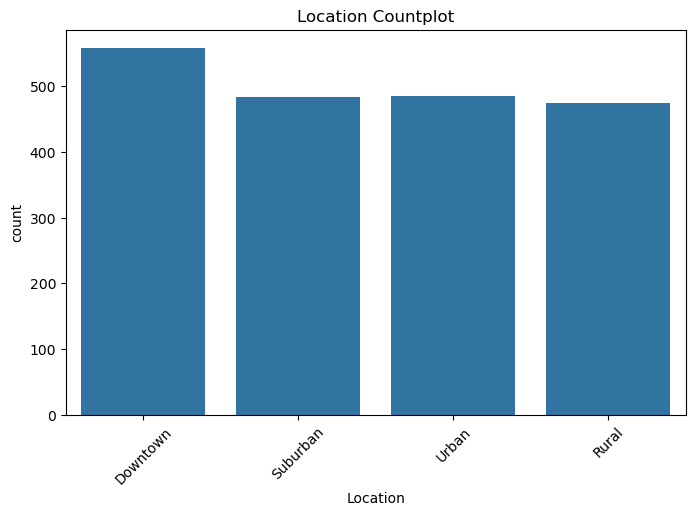

In [17]:
# Countplot for Location
plt.figure(figsize=(8,5))
sns.countplot(x=df["Location"])
plt.title("Location Countplot")
plt.xticks(rotation=45)
plt.show()

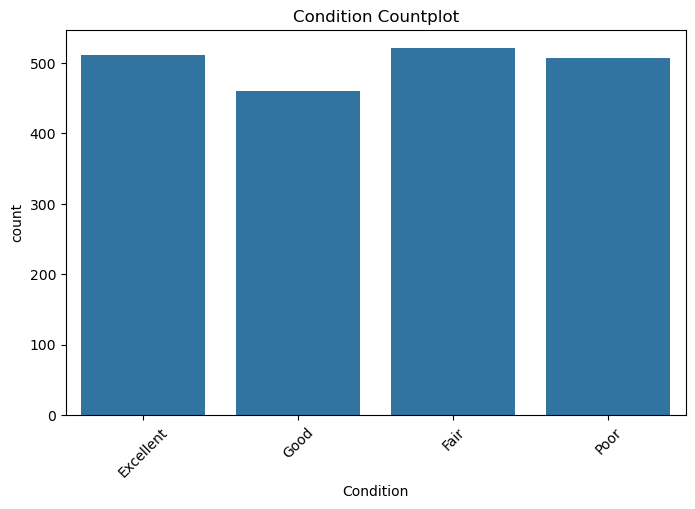

In [18]:
# Countplot for Condition
plt.figure(figsize=(8,5))
sns.countplot(x=df["Condition"])
plt.title("Condition Countplot")
plt.xticks(rotation=45)
plt.show()

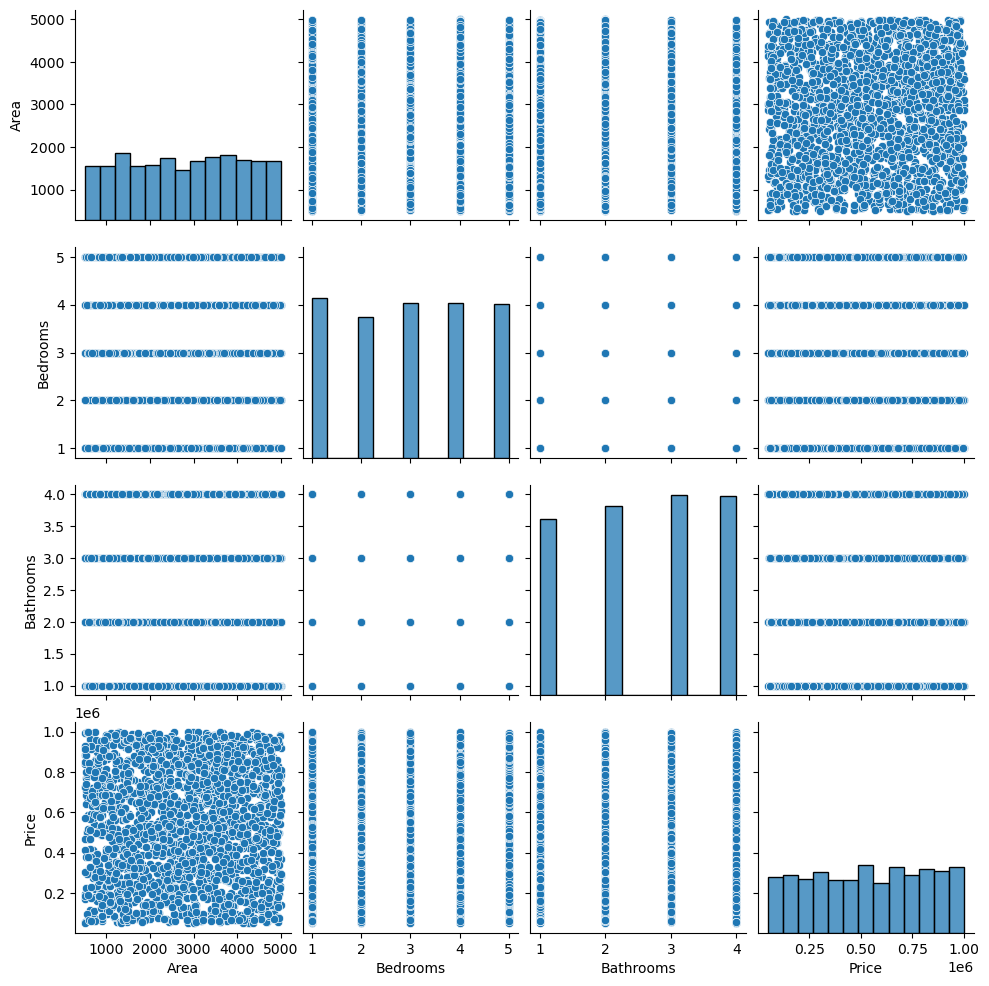

In [19]:
# Pairplot
sns.pairplot(df[["Area","Bedrooms","Bathrooms","Price"]])
plt.show()

In [20]:
# Numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price'], dtype='object')


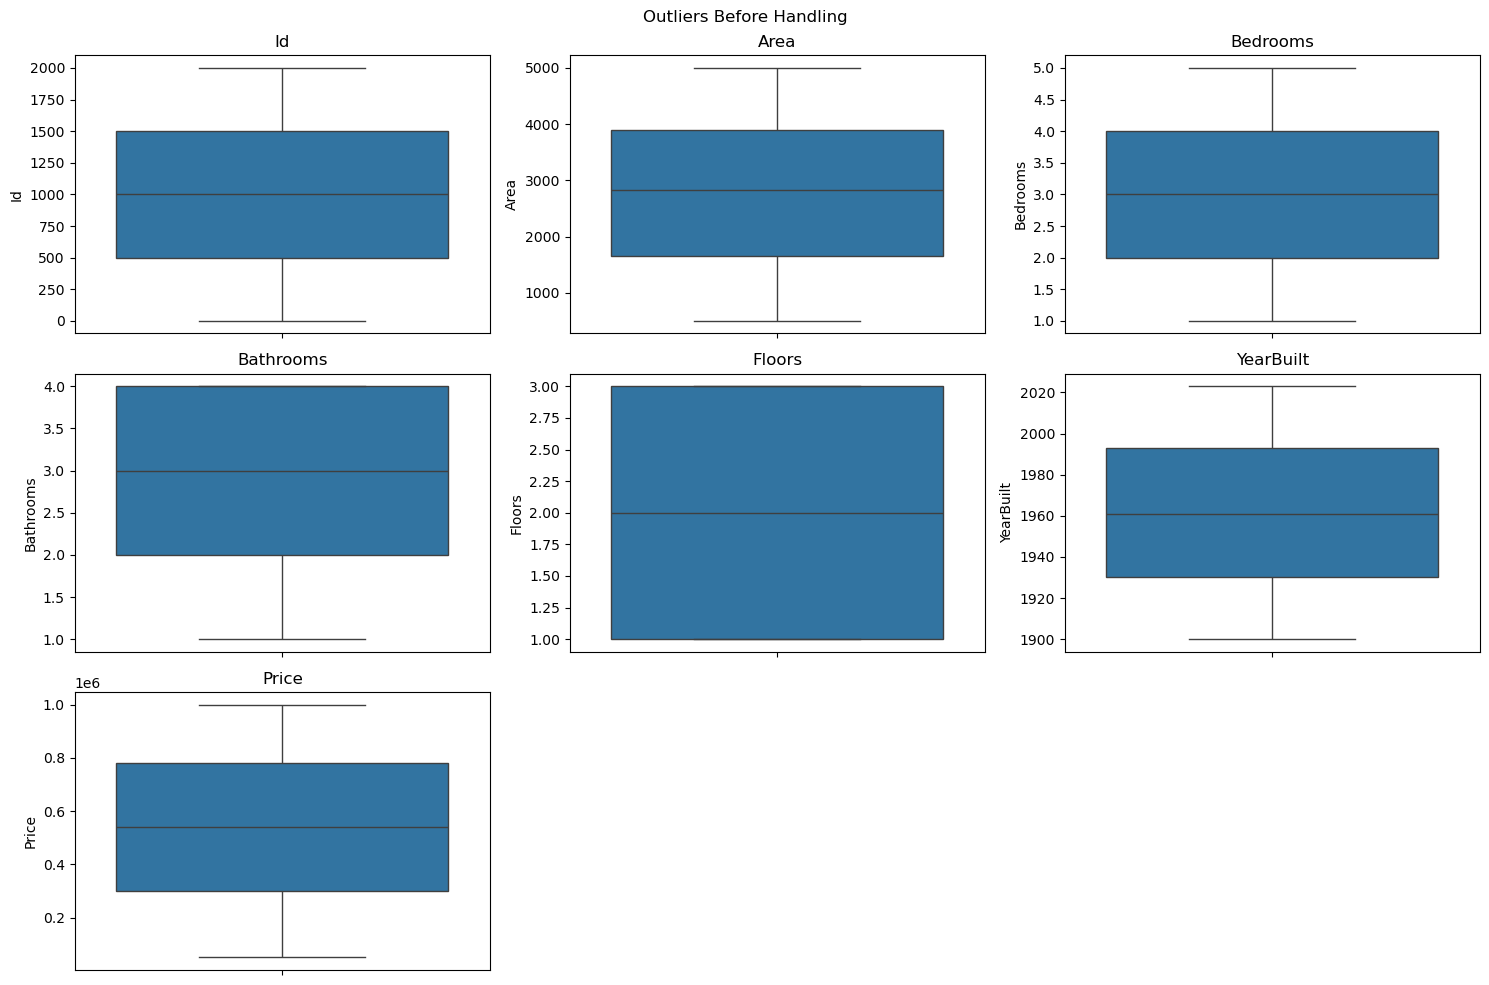

In [21]:
# Boxplots before handling outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle("Outliers Before Handling")
plt.tight_layout()
plt.show()

In [22]:
# Shape before removing outliers
print("Shape Before:", df.shape)

Shape Before: (2000, 10)


In [23]:
# Remove outliers except Price
outlier_cols = [col for col in num_cols if col != "Price"]

for col in outlier_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

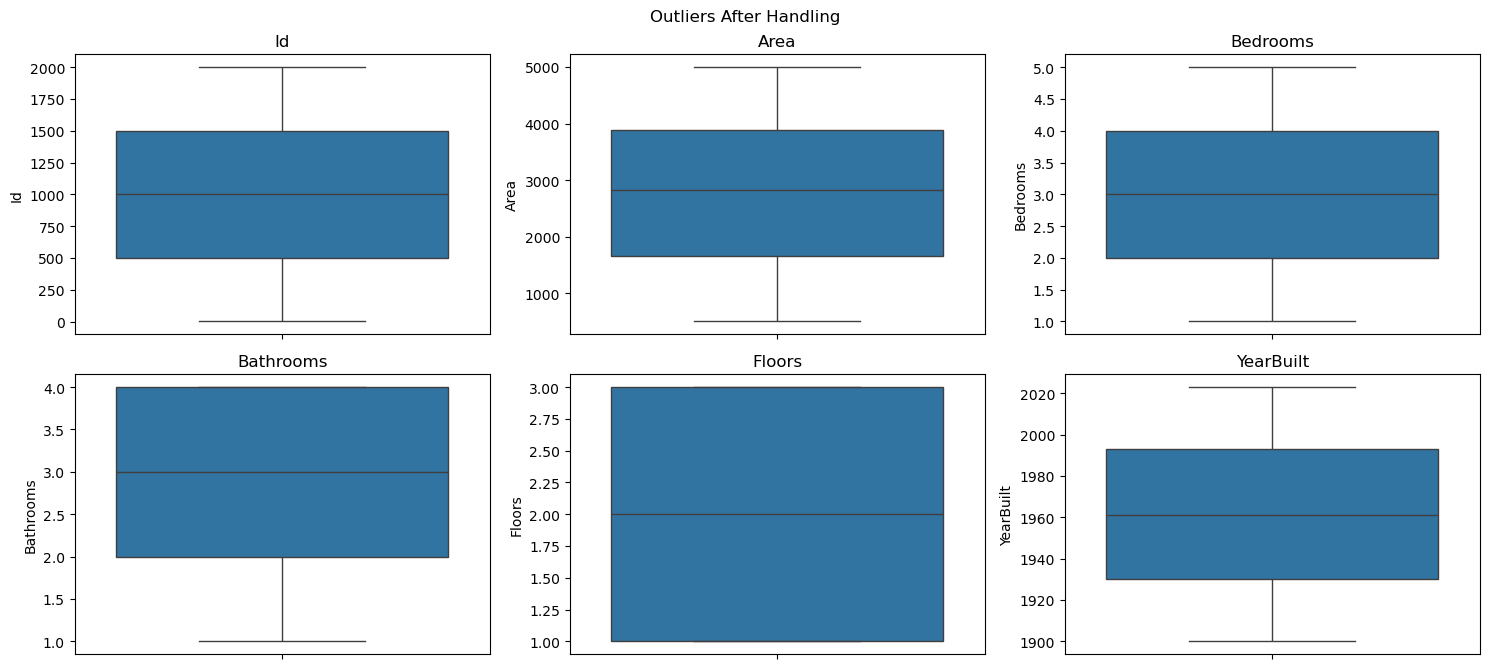

In [25]:
# Boxplots after handling outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle("Outliers After Handling")
plt.tight_layout()
plt.show()

In [26]:
# Drop Id column
df = df.drop("Id", axis=1)

In [28]:
df.columns.tolist()

['Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'YearBuilt',
 'Location',
 'Condition',
 'Garage',
 'Price']

In [29]:
# One hot encoding
df = pd.get_dummies(df, columns=["Location","Condition"], drop_first=True)

In [30]:
# Display encoded dataset
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,No,149919,False,False,False,False,False,False
1,4272,5,4,3,1958,No,424998,False,False,False,False,False,False
2,3592,2,2,3,1938,No,266746,False,False,False,False,True,False
3,966,4,2,2,1902,Yes,244020,False,True,False,True,False,False
4,4926,1,4,2,1975,Yes,636056,False,False,False,True,False,False


In [32]:
# Features
X = df.drop("Price", axis=1)
# Target
y = df["Price"]
X
y

0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64

In [34]:
# Check remaining categorical columns
X.dtypes

Area                  int64
Bedrooms              int64
Bathrooms             int64
Floors                int64
YearBuilt             int64
Garage               object
Location_Rural         bool
Location_Suburban      bool
Location_Urban         bool
Condition_Fair         bool
Condition_Good         bool
Condition_Poor         bool
dtype: object

In [35]:
# Encode Garage column
X = pd.get_dummies(X, columns=["Garage"], drop_first=True)

In [36]:
# Check data types again
X.dtypes

Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors               int64
YearBuilt            int64
Location_Rural        bool
Location_Suburban     bool
Location_Urban        bool
Condition_Fair        bool
Condition_Good        bool
Condition_Poor        bool
Garage_Yes            bool
dtype: object

In [37]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler
# Create scaler
scaler = StandardScaler()
# Scale features
X_scaled = scaler.fit_transform(X)
# Display scaled shape
X_scaled.shape

(2000, 12)

In [38]:
# Sample scaled values
X_scaled[:5]

array([[-1.10147065,  1.40179052,  1.30556821,  1.24415065,  0.23815548,
        -0.55732934, -0.56426196, -0.5658021 , -0.5935192 , -0.54730719,
        -0.58273899, -0.96269532],
       [ 1.14748543,  1.40179052,  1.30556821,  1.24415065, -0.09594152,
        -0.55732934, -0.56426196, -0.5658021 , -0.5935192 , -0.54730719,
        -0.58273899, -0.96269532],
       [ 0.62231712, -0.70458141, -0.49832569,  1.24415065, -0.65276985,
        -0.55732934, -0.56426196, -0.5658021 , -0.5935192 ,  1.82712747,
        -0.58273899, -0.96269532],
       [-1.40575935,  0.69966655, -0.49832569,  0.00803475, -1.65506085,
        -0.55732934,  1.77222649, -0.5658021 ,  1.68486545, -0.54730719,
        -0.58273899,  1.03875025],
       [ 1.65257379, -1.40670539,  1.30556821,  0.00803475,  0.37736256,
        -0.55732934, -0.56426196, -0.5658021 ,  1.68486545, -0.54730719,
        -0.58273899,  1.03875025]])

In [40]:
# Import train_test_split
from sklearn.model_selection import train_test_split
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Training shape
X_train.shape

(1600, 12)

In [42]:
# Testing shape
X_test.shape

(400, 12)

In [43]:
# y_train shape
y_train.shape

(1600,)

In [44]:
# y_test shape
y_test.shape

(400,)

In [45]:
# Import model
from sklearn.ensemble import RandomForestRegressor
# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
# Train model
model.fit(X_train, y_train)
# Predict values
y_pred = model.predict(X_test)
# Training message
print("Model trained successfully")

Model trained successfully


In [49]:
# Comparison dataframe
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

In [50]:
# Display first 10 rows
comparison.head(10)

,Actual Price,Predicted Price
1860,514764,612142.59
353,694256,464462.83
1333,66375,567264.79
905,650243,498368.47
1289,223285,519130.03
1273,468127,562724.88
938,513002,523402.32
1731,911525,591791.12
65,723265,598386.21
1323,339416,616566.99


In [51]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [52]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
# MSE
mse = mean_squared_error(y_test, y_pred)    
print("MSE:", mse)
#rmse
rmse = np.sqrt(mse)
print("RMSE:", rmse)
# R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


MAE: 252477.50920000003
MSE: 85278228697.37944
RMSE: 292024.36319146294
R² Score: -0.09613769666939098


In [53]:
# Feature importance dataframe
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [54]:
importance






,Feature,Importance
0,Area,0.323898
1,Bedrooms,0.094241
2,Bathrooms,0.071979
3,Floors,0.047900
4,YearBuilt,0.262667
5,Location_Rural,0.030484
6,Location_Suburban,0.026661
7,Location_Urban,0.028876
8,Condition_Fair,0.026714
9,Condition_Good,0.025998


In [55]:
# Sort importance
importance = importance.sort_values(by="Importance", ascending=False)

In [56]:
importance

,Feature,Importance
0,Area,0.323898
4,YearBuilt,0.262667
1,Bedrooms,0.094241
2,Bathrooms,0.071979
3,Floors,0.047900
11,Garage_Yes,0.033980
5,Location_Rural,0.030484
7,Location_Urban,0.028876
8,Condition_Fair,0.026714
6,Location_Suburban,0.026661


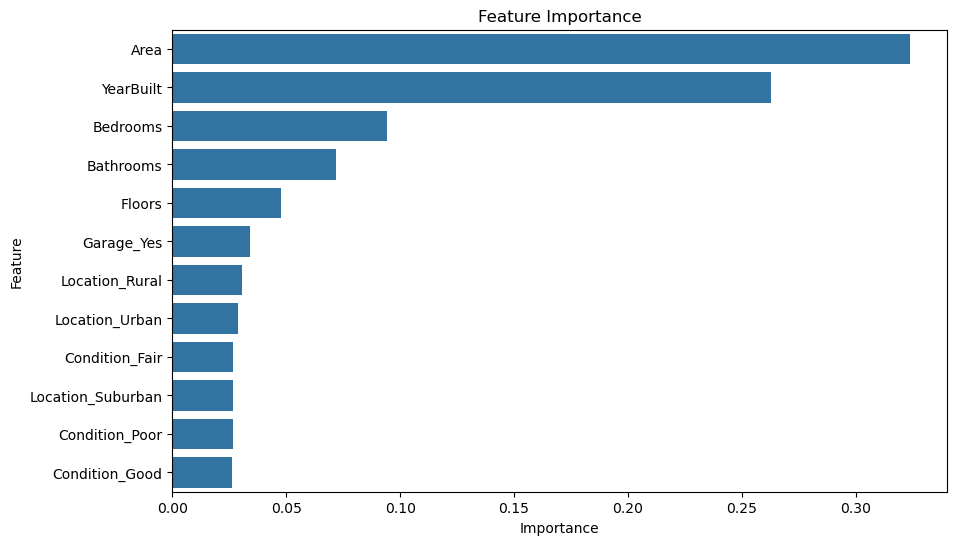

Features with higher importance affect house price more.


In [58]:
# Feature importance plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()
# Important feature explanation
print("Features with higher importance affect house price more.")

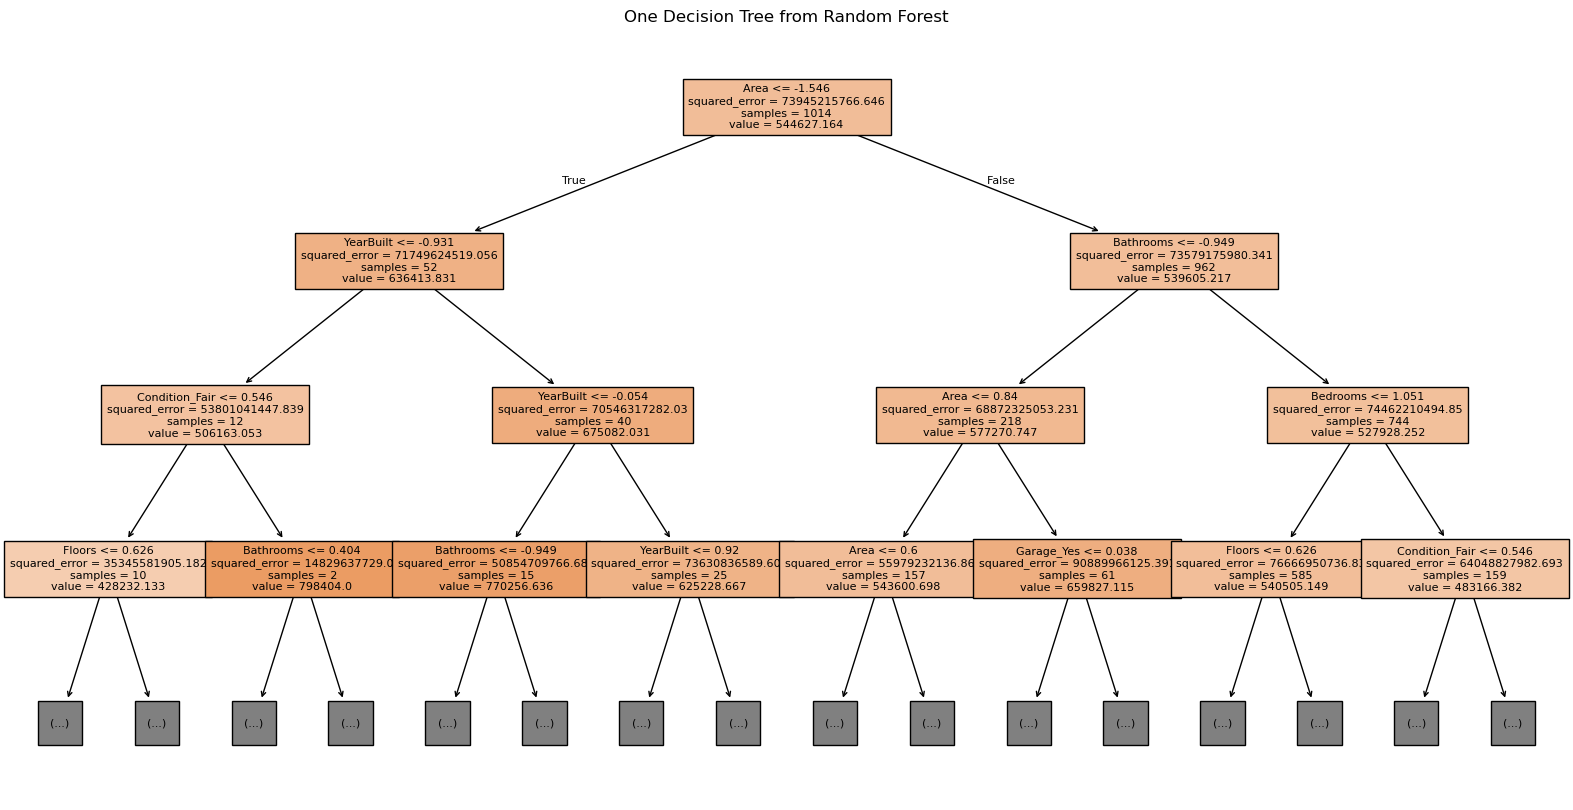

In [61]:
# Import tree visualization
from sklearn.tree import plot_tree

# Visualize one tree from Random Forest
plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[1],
    filled=True,
    feature_names=X.columns,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from Random Forest")

plt.show()

In [ ]:
# Tree explanation
print("This is only one tree inside the forest.")
print("Final prediction comes from multiple trees working together.")